# Market-world variant: `relo`

This notebook is the stage-3 analysis re-run on the per-world bills of the `relo` market world (stage-2 variant of the same name; see `z-ethan/market_transfer/methods.md`). The observation calendar, the cost ensemble, the noise model, the seed, and the cell order are identical to the base notebook, so every noise history pairs with its base counterpart; only the bills and the cap unit change. Every output carries the suffix `_relo`.

# Bridge detection — stage 3: the imperfect observer

**Who this is for.** This notebook is written to be readable without a
technical background. Every term of art gets a short explanation, in
parentheses, at its first use. It continues stages 1 and 2 (`bridge_detection
.ipynb`, `bridge_detection_stage2.ipynb`). The methods are also written up in
`methods.md` next to this notebook.

**Why stage 3 exists.** Stages 1 and 2 gave the observer perfect vision: it
saw each year's true build cost exactly, and a tolerance band merely stood in
for noise. Every quoted year therefore carried the caveat "best case for a
perfect observer." Stage 3 replaces the stand-in with a real noise model. The
observer now sees what a real cost-watcher would see: the reported costs of
the individual completed plants, scattered by random overruns and underruns
(an overrun: a project that comes in above its expected cost). The caveat
becomes a measured result.

**The noise model, in words.** Observations happen at the model's solve years
(the years the power-system model actually steps through) that have new
builds. In such a year the schedule completes n units (the capacity added
since the last solve year, divided by the 300-megawatt unit size). Each
completed unit's reported cost is the world's true cost for that year,
multiplied by:

- an industry-wide yearly shock (a random factor shared by all of that year's
  units — good and bad years for the whole industry; spread tau). This factor
  matters: without it, a big schedule completes so many units that averaging
  washes the project noise out, and the observer becomes nearly perfect
  again;
- the project's own random overrun or underrun (a lognormal factor — skewed,
  so large overruns are more likely than equally large underruns; spread
  sigma);
- in the bias experiment only, a systematic overrun factor (1 + m) that
  shifts every project the same way.

The observer's yearly reading is the geometric mean of the unit costs (the
average taken in logarithms — the natural average for skewed data). Three
noise levels are fixed in advance: (sigma, tau) = (0.15, 0.05), (0.30, 0.10),
(0.50, 0.20). These are declared dials, not estimates from data; results are
reported at all three. Ten noise histories (replications) are simulated per
true world.

**The observer, upgraded from elimination to weighting.** Under noise,
keep-or-kill is wrong: a world just outside a band is unlikely, not
impossible. Each of the 10,000 worlds now carries a running weight: how
probable the observed readings would be if that world were true. Larger
misses count more, and a reading based on more units, or on a calmer industry
year, counts more. Every stage-2 quantity becomes its weighted version. Years
with no completed units contribute nothing — no builds, no data. The main
observer is assumed to know the noise model (the true sigma, tau, and unit
counts). That is a generous assumption, and it is stated as such wherever
numbers are quoted.

**Rules fixed before the run** (gates H1–H3, in `status.md`): the alarm keeps
its 5% false-alarm budget on held-out worlds (H1); low noise must land near
the stage-2 tight-band results (H2, consistency); the middle noise level must
still detect by 2045 in every schedule for a PASS (H3).

Tables continue the numbering (`b14` and up), figures likewise (`d09` and
up). Run on the **playground-env** kernel.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import sys
sys.path.insert(0, str(Path.cwd().parent))
import plotstyle as ps
ps.apply()

pd.set_option("display.width", 220)
SENS = "relo"          # step4 market world (BD_SENS)
SFX = "_relo"

HERE = Path.cwd()
assert HERE.name == "bridge_detection", f"run from z-ethan/bridge_detection/, not {HERE}"
REPO = HERE.parents[1]
EXPORTS = HERE / "exports"
FIGURES = HERE / "figures"

MC_EXPORTS = REPO / "z-ethan" / "mc" / "exports"
CHECKS3 = REPO / "z-ethan" / "step3_checks" / "exports"
S3ANALYSIS = REPO / "z-ethan" / "step3_analysis" / "exports"

# ---- the MC ensemble --------------------------------------------------------------
Z = np.load(MC_EXPORTS / "mc_perdraw.npz")
META = json.loads(str(Z["meta_json"]))
assert META["n_draws"] == 10000 and META["master_seed"] == 20260715, META
YEARS_MC = Z["years"]
YI = {int(y): i for i, y in enumerate(YEARS_MC)}

SCHEDULES = ["eia", "aj", "iaea", "mck", "cop28", "eo"]  # ambition order
AB2TOK = {"eia": "eia_aeo_high", "aj": "abou_jaoude", "iaea": "iaea_high",
          "mck": "mckinsey", "cop28": "cop28", "eo": "eo2025"}
TOK2AB = {v: k for k, v in AB2TOK.items()}
NAME2AB = {str(n): TOK2AB[str(t)] for n, t in zip(Z["sched_order"], Z["scen_tokens"])}

reg_smr = pd.read_csv(MC_EXPORTS / "smr100" / "selected_draws.csv")
reg_smr["ab"] = reg_smr["schedule"].map(NAME2AB)
ANCH = {ab: {} for ab in SCHEDULES}
for _, r in reg_smr.iterrows():
    ANCH[r["ab"]][r["percentile"]] = int(r["draw_index"])

# ---- stage-2 per-world bills and labels -------------------------------------------
BW = np.load(EXPORTS / f"b07_bills_perworld{SFX}.npz")
OBS_YEARS = [int(y) for y in BW["obs_years"]]
B2050 = {ab: BW[f"b2050_{ab}"] for ab in SCHEDULES}
BILLS_T = {ab: BW[f"bills_{ab}"] for ab in SCHEDULES}
BADW = {ab: BW[f"bad_{ab}"].astype(bool) for ab in SCHEDULES}

t08 = pd.read_csv(S3ANALYSIS / "t08_rental_transfer.csv").set_index("case")
# market world SENS: the cap unit is the in-world middle-world bill written
# by stage 2; the published t08 (base world) enters only as a soft ratio.
P50BILL = {ab: float(BW[f"p50bill_{ab}"]) for ab in SCHEDULES}
for ab in SCHEDULES:
    assert abs(B2050[ab][ANCH[ab]["p50"]] - P50BILL[ab]) <= 1e-6, ab
_ratio = [B2050[ab][ANCH[ab][p]]
          / float(t08.loc[f"smr100_{ab}_{p}", "PV_rental_transfer_2024B"])
          for ab in SCHEDULES for p in ["p05", "p50", "p95"]]
print(f"stage-2 bills loaded ({SENS}); in-world anchor bills / published base "
      f"bills range {min(_ratio):.3f}-{max(_ratio):.3f}")

# ---- the observation calendar: solve years with new builds ------------------------
UNIT_MW = 300
duals3 = pd.read_csv(CHECKS3 / "duals_by_year.csv")
FLOOR = duals3[duals3["t"] <= 2030].groupby("case")["mandate_MW"].max()
duals3["program_MW"] = (duals3["mandate_MW"]
                        - duals3["case"].map(FLOOR).fillna(0.0)).clip(lower=0.0)

OBSCAL, N_UNITS, LOGOCC = {}, {}, {}
cal_rows = []
LEVELS = [(0.15, 0.05), (0.30, 0.10), (0.50, 0.20)]
for ab in SCHEDULES:
    d = duals3[duals3["case"] == f"smr100_{ab}_p05"].set_index("t").sort_index()
    ts = [int(t) for t in d.index if t >= 2031]
    prev = 0.0
    years, units = [], []
    for t in ts:
        add = float(d.loc[t, "program_MW"]) - prev
        prev = float(d.loc[t, "program_MW"])
        if add > 0:
            years.append(t)
            units.append(max(1, int(round(add / UNIT_MW))))
    OBSCAL[ab] = np.array(years)
    N_UNITS[ab] = np.array(units, dtype=float)
    occ = Z[f"occ_{AB2TOK[ab]}_smr"]
    LOGOCC[ab] = np.log(occ[:, [YI[t] for t in years]])
    for t, n in zip(years, units):
        row = dict(schedule=ab, year=t, n_units=n)
        for sig, tau in LEVELS:
            row[f"eff_sd_s{int(sig*100)}"] = round(float(np.sqrt(tau**2 + sig**2 / n)), 3)
        cal_rows.append(row)
b14 = pd.DataFrame(cal_rows)
b14.to_csv(EXPORTS / f"b14_observation_calendar{SFX}.csv", index=False)
print(b14.to_string(index=False))


stage-2 bills loaded (relo); in-world anchor bills / published base bills range 1.047-1.802


schedule  year  n_units  eff_sd_s15  eff_sd_s30  eff_sd_s50
     eia  2038       33       0.056       0.113       0.218
     eia  2041       22       0.059       0.119       0.227
     eia  2044        1       0.158       0.316       0.539
     eia  2047        1       0.158       0.316       0.539
     eia  2050       12       0.066       0.132       0.247
      aj  2031        1       0.158       0.316       0.539
      aj  2032        1       0.158       0.316       0.539
      aj  2033        1       0.158       0.316       0.539
      aj  2034        1       0.158       0.316       0.539
      aj  2035        1       0.158       0.316       0.539
      aj  2038       11       0.067       0.135       0.250
      aj  2041       13       0.065       0.130       0.243
      aj  2044       17       0.062       0.124       0.234
      aj  2047       28       0.057       0.115       0.221
      aj  2050       45       0.055       0.110       0.213
    iaea  2031       11       0.067     

## B14/B15 — the observation calendar and what noise looks like

The table above is the observer's data supply: for each schedule, the years
with completed units, how many units, and the effective spread of the yearly
reading at each noise level (the combined effect of the shared industry shock
and the project scatter averaged over that year's units). Two things to
notice. First, the smallest schedule (eia) completes nothing before 2038 —
its observer has no data at all until then. Second, in heavy build years the
project scatter averages down but the industry-wide shock does not: the
effective spread never falls below tau. That floor is what keeps the exercise
honest for the big schedules.

The figure below shows one expensive (no-decay) world per noise level: the
true cost curve, the simulated unit costs (dots), and the yearly geometric
means the observer actually gets to see (crosses).

saved -> figures\d09_noise_illustration_relo.png


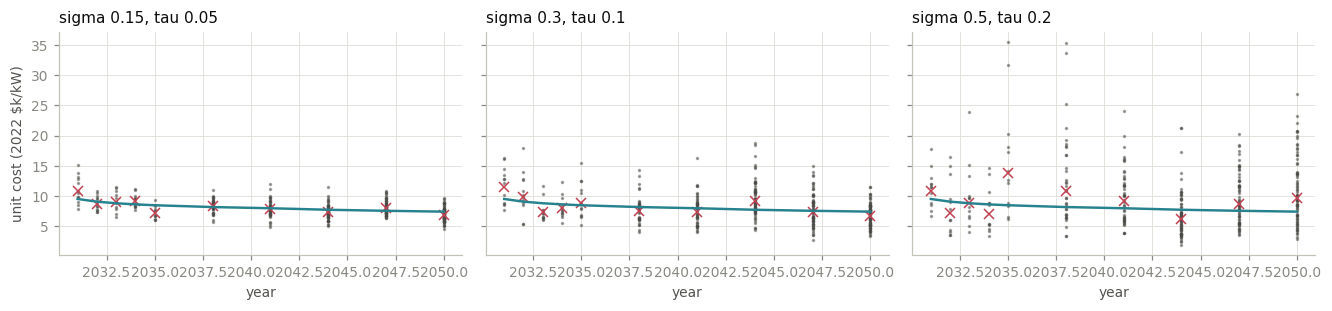

In [2]:
SIGN = {lv: f"s{int(lv[0]*100)}t{int(lv[1]*100)}" for lv in LEVELS}
rng = np.random.default_rng(20260821)
R = 10

# d09: noise illustration on one no-decay world (mck, its p95 anchor draw)
ab0 = "mck"
w0 = ANCH[ab0]["p95"]
fig, axes = plt.subplots(1, 3, figsize=(ps.W1 * 1.9, 2.9), sharey=True)
for ax, (sig, tau) in zip(axes, LEVELS):
    years, units = OBSCAL[ab0], N_UNITS[ab0]
    true_c = np.exp(LOGOCC[ab0][w0])
    for j, (t, n) in enumerate(zip(years, units)):
        eta = rng.normal(0, tau)
        zc = true_c[j] * np.exp(eta + rng.normal(0, sig, size=int(n)))
        ax.plot([t] * int(n), zc / 1e3, ".", color=ps.BASE_C, ms=2.5, alpha=0.45)
        gm = float(np.exp(np.log(zc).mean()))
        ax.plot(t, gm / 1e3, "x", color=ps.ACCENT["red"], ms=6)
    ax.plot(years, true_c / 1e3, color=ps.SCHED_C[ab0], lw=1.6)
    ax.set_title(f"sigma {sig}, tau {tau}")
    ax.set_xlabel("year")
axes[0].set_ylabel("unit cost (2022 $k/kW)")
fig.tight_layout()
ps.savefig(fig, FIGURES / f"d09_noise_illustration{SFX}.png")
plt.show()


## The weighted sweep — one computation feeds B16–B19

For each schedule, noise level, and sampled true world, we simulate ten noise
histories. For each history, every one of the 10,000 worlds gets a running
weight: how probable the observed readings so far would be if that world were
true (a standard likelihood computation — the formula is in `methods.md`).
From the weights we track, after each observation:

- the updated probability that the world is a no-decay world (C1);
- the weighted 10th/50th/90th percentiles of the 2050 total bill, stored at
  the snapshot years 2035, 2040, 2045, 2050;
- for every cap X on the cap grid, two updated probabilities that the 2050
  bill exceeds X. The **costs-only** version uses the cost readings alone
  (the original pre-registered information set; kept as a reference). The
  **spend-aware** version — the standard since the 2026-08-25 amendment
  (Ethan; logged in `status.md`) — also lets the observer read the
  government's own outlay ledger, every year: each candidate world's total
  is scored as the spend observed so far plus that world's remaining
  payments. Spend enters additively only — it is never used to tell worlds
  apart, because in-model payments are exact shadow prices and would
  identify the world instantly. Once actual spend reaches the cap, no
  candidate total can stay below it, so the alarm fires by construction (an
  explicit ledger backstop guards the numerical clip edge). The ledger is
  read every calendar year — the bill arithmetic accrues annually — so
  spend at detection can overshoot the cap by at most one year's payment.

Samples per schedule and noise level: 300 no-decay worlds and 300 decay
worlds (the working sample), plus 300 untouched decay worlds whose only job
is to verify the alarm's false-alarm rate (gate H1). Seed 20260821.

In [3]:
# Cap grid: extended below the 1.0x floor on 2026-08-25 (amendment, see
# status.md) down to wherever the starting probability of exceedance stays
# at or under PRIOR_CEIL (~the cap at the 25th-percentile bill).
MULT = np.round(np.arange(0.45, 2.51, 0.05), 2)
PRIOR_CEIL = 0.755
EXCEED = {ab: (B2050[ab][:, None] > (MULT * P50BILL[ab])[None, :]).astype(float)
          for ab in SCHEDULES}
BILL_ORDER = {ab: np.argsort(B2050[ab]) for ab in SCHEDULES}
PRIOR_Q = {ab: np.percentile(B2050[ab], [10, 50, 90]) for ab in SCHEDULES}
SNAP_YEARS = [2035, 2040, 2045, 2050]

# the annual ledger (2026-08-25 amendment): per annual year, each world's
# remaining bill after that year, pre-sorted for the composite-total lookup
ANNUAL_YEARS = np.arange(2031, 2051)
CUMU = {ab: np.cumsum(N_UNITS[ab]) for ab in SCHEDULES}
OBS_J = {ab: np.searchsorted(OBSCAL[ab], ANNUAL_YEARS, side="right")
         for ab in SCHEDULES}
FUT_ORDER, FUT_SORTED = {}, {}
for ab in SCHEDULES:
    fo, fs = [], []
    for i_ in range(len(ANNUAL_YEARS)):
        f_ = B2050[ab] - BILLS_T[ab][:, i_]
        o_ = np.argsort(f_)
        fo.append(o_)
        fs.append(f_[o_])
    FUT_ORDER[ab], FUT_SORTED[ab] = fo, fs

N_S = 300
SAMP, HOLDW, IS_BAD_S = {}, {}, {}
for ab in SCHEDULES:
    bad_idx = np.flatnonzero(BADW[ab])
    good_idx = np.flatnonzero(~BADW[ab])
    s_bad = rng.choice(bad_idx, size=min(N_S, len(bad_idx)), replace=False)
    s_good = rng.choice(good_idx, size=min(N_S, len(good_idx)), replace=False)
    rest = np.setdiff1d(good_idx, s_good)
    h_good = rng.choice(rest, size=min(N_S, len(rest)), replace=False)
    SAMP[ab] = np.concatenate([s_bad, s_good])
    HOLDW[ab] = h_good
    IS_BAD_S[ab] = BADW[ab][SAMP[ab]]

def wquant(bills_sorted, w_sorted, qs=(0.1, 0.5, 0.9)):
    cw = np.cumsum(w_sorted)
    cw /= cw[-1]
    return bills_sorted[np.searchsorted(cw, qs)]

def weighted_sweep(ab, lv, worlds, m_data=0.0, m_obs=0.0,
                   want_bills=False, want_ex=False, want_ex_spend=False):
    sig, tau = lv
    L0 = LOGOCC[ab]                          # (10000, K)
    n = N_UNITS[ab]
    var = tau ** 2 + sig ** 2 / n            # (K,)
    K = L0.shape[1]
    bad = BADW[ab].astype(float)
    order = BILL_ORDER[ab]
    bills_sorted = B2050[ab][order]
    E = EXCEED[ab]
    Xv = MULT * P50BILL[ab]
    snap_j = [int((OBSCAL[ab] <= T).sum()) for T in SNAP_YEARS]  # obs count by snapshot
    nW = len(worlds)
    nY = len(ANNUAL_YEARS)
    post = np.empty((nW, R, K), dtype=np.float32)
    ex = np.empty((nW, R, K, len(MULT)), dtype=np.float32) if want_ex else None
    ex1 = (np.empty((nW, R, nY, len(MULT)), dtype=np.float32)
           if want_ex_spend else None)
    qs = np.empty((nW, R, len(SNAP_YEARS), 3), dtype=np.float32) if want_bills else None
    shift = np.log1p(m_data) - np.log1p(m_obs)
    for i, w in enumerate(worlds):
        eta = rng.normal(0, tau, size=(K, R))
        zbar = rng.normal(0, 1, size=(K, R)) * (sig / np.sqrt(n))[:, None]
        Y = L0[w][:, None] + shift + eta + zbar   # observed log geo-means, net of observer's bias correction
        D = (L0[:, :, None] - Y[None, :, :]) ** 2 / (2 * var)[None, :, None]
        cl = -np.cumsum(D, axis=1)                # (10000, K, R) cumulative log-likelihood
        cl -= cl.max(axis=0, keepdims=True)
        W = np.exp(cl)
        tw = W.sum(axis=0)                        # (K, R)
        Wf = W.reshape(10000, K * R)
        post[i] = np.clip((bad @ Wf).reshape(K, R) / tw, 1e-9, 1 - 1e-9).T
        if want_ex:
            ex[i] = ((E.T @ Wf).reshape(len(MULT), K, R) / tw).transpose(2, 1, 0)
        if want_ex_spend:
            # spend-aware exceedance, read at every annual year: the weighted
            # share of worlds whose remaining bill exceeds X minus the truth
            # world's observed sunk spend. Cost weights are held from the
            # last observation year; spend enters additively only.
            Bw = BILLS_T[ab][w]
            for yi_ in range(nY):
                j = int(OBS_J[ab][yi_])
                if j == 0:
                    Wo = np.ones((10000, R))
                    twy = np.full(R, 10000.0)
                else:
                    Wo = W[:, j - 1, :]
                    twy = tw[j - 1]
                Ws = Wo[FUT_ORDER[ab][yi_]]
                tail = np.concatenate(
                    [np.flip(np.cumsum(np.flip(Ws, axis=0), axis=0), axis=0),
                     np.zeros((1, R))], axis=0)
                pos = np.searchsorted(FUT_SORTED[ab][yi_], Xv - Bw[yi_],
                                      side="right")
                ex1[i, :, yi_, :] = np.clip((tail[pos] / twy).T,
                                            1e-9, 1 - 1e-9)
        if want_bills:
            for si, j in enumerate(snap_j):
                if j == 0:
                    qs[i, :, si] = PRIOR_Q[ab]
                else:
                    for r_ in range(R):
                        qs[i, r_, si] = wquant(bills_sorted, W[order, j - 1, r_])
    return dict(post=post, ex=ex, ex_spend=ex1, qs=qs)

RES3, RESH3 = {}, {}
for ab in SCHEDULES:
    for lv in LEVELS:
        RES3[(ab, lv)] = weighted_sweep(ab, lv, SAMP[ab], want_bills=True,
                                        want_ex=True, want_ex_spend=True)
        RESH3[(ab, lv)] = weighted_sweep(ab, lv, HOLDW[ab],
                                         want_ex_spend=True)
        print(f"swept {ab} {SIGN[lv]}")


swept eia s15t5


swept eia s30t10


swept eia s50t20


swept aj s15t5


swept aj s30t10


...

swept cop28 s30t10


swept cop28 s50t20


swept eo s15t5


swept eo s30t10


swept eo s50t20


## B16 — C1 detection with noisy data

The alarm is the stage-2 calibrated rule, unchanged: the bar is set from the
sampled good worlds' histories so that at most 5% of good-world histories
ever trigger a false alarm by 2050 (set conservatively, at an expected 3.5%,
to leave room for sampling error), then verified on the untouched sample.
Detection can only happen at an observation year — the observer cannot learn
in years with no completed units.

The table joins the stage-2 perfect-observer results (tight 5% band and loose
20% band) for comparison. Read the gap between those columns and the noisy
columns as the price of realistic data.

In [4]:
def conformal_bar(maxvals, alpha=0.035):
    n = len(maxvals)
    k = min(int(np.ceil((n + 1) * (1 - alpha))), n)
    return float(np.sort(maxvals)[k - 1])

b09 = pd.read_csv(EXPORTS / f"b09_detection_calibrated{SFX}.csv")
S2MED = {(r["schedule"], r["delta"]): r["median_det_year"]
         for _, r in b09.iterrows()}

CSTAR3, DET3 = {}, {}
rows = []
for ab in SCHEDULES:
    isb = IS_BAD_S[ab]
    yrs = OBSCAL[ab]
    for lv in LEVELS:
        post = RES3[(ab, lv)]["post"]
        maxg = post[~isb].max(axis=2).ravel()
        c = conformal_bar(maxg)
        CSTAR3[(ab, lv)] = c
        fpr_cal = float((post[~isb].max(axis=2) > c).mean())
        fpr_hold = float((RESH3[(ab, lv)]["post"].max(axis=2) > c).mean())
        pb = post[isb]                          # (300, R, K)
        hit = pb > c
        fired = hit.any(axis=2)                 # (300, R)
        firstj = hit.argmax(axis=2)
        years = yrs[firstj]
        got = years[fired]
        DET3[(ab, lv)] = dict(fired=fired, firstj=firstj)
        rows.append(dict(
            schedule=ab, sigma=lv[0], tau=lv[1], c_star=round(c, 4),
            share_detected=round(float(fired.mean()), 3),
            median_det_year=int(np.median(got)) if fired.any() else None,
            q25=int(np.percentile(got, 25)) if fired.any() else None,
            q75=int(np.percentile(got, 75)) if fired.any() else None,
            share_det_by_2045=round(float((fired & (years <= 2045)).mean()), 3),
            fpr_calibration=round(fpr_cal, 3),
            fpr_holdout=round(fpr_hold, 3),
            stage2_median_d05=S2MED[(ab, 0.05)],
            stage2_median_d20=S2MED[(ab, 0.20)]))
b15 = pd.DataFrame(rows)
b15.to_csv(EXPORTS / f"b15_detection_noisy{SFX}.csv", index=False)
print(b15.to_string(index=False))


schedule  sigma  tau  c_star  share_detected  median_det_year  q25  q75  share_det_by_2045  fpr_calibration  fpr_holdout  stage2_median_d05  stage2_median_d20
     eia   0.15 0.05  0.9727           0.627             2038 2038 2041              0.538            0.035        0.051               2037               2037
     eia   0.30 0.10  0.9775           0.503             2038 2038 2041              0.434            0.035        0.040               2037               2037
     eia   0.50 0.20  0.9804           0.400             2041 2041 2044              0.308            0.035        0.040               2037               2037
      aj   0.15 0.05  0.9603           0.775             2041 2041 2047              0.566            0.035        0.036               2035               2038
      aj   0.30 0.10  0.9538           0.573             2044 2041 2047              0.328            0.035        0.042               2035               2038
      aj   0.50 0.20  0.9433           0.433  

saved -> figures\d10_detection_ecdf_noisy_relo.png


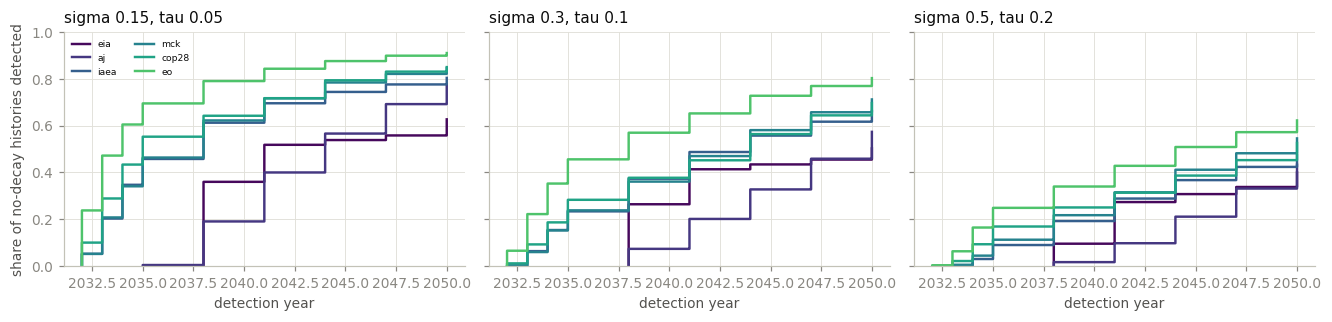

In [5]:
# ---- d10: detection-year ECDFs by noise level ------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(ps.W1 * 1.9, 3.0), sharey=True)
for ax, lv in zip(axes, LEVELS):
    for ab in SCHEDULES:
        fired = DET3[(ab, lv)]["fired"]
        years = OBSCAL[ab][DET3[(ab, lv)]["firstj"]][fired]
        got = np.sort(years)
        n_all = fired.size
        if len(got):
            ecdf_x = np.concatenate([got, [2050]])
            ecdf_y = np.concatenate([np.arange(1, len(got) + 1), [len(got)]]) / n_all
            ax.step(ecdf_x, ecdf_y, where="post", color=ps.SCHED_C[ab],
                    lw=1.6, label=ab)
    ax.set_title(f"sigma {lv[0]}, tau {lv[1]}")
    ax.set_xlabel("detection year")
    ax.set_ylim(0, 1)
axes[0].set_ylabel("share of no-decay histories detected")
axes[0].legend(ncols=2, fontsize=6, loc="upper left")
fig.tight_layout()
ps.savefig(fig, FIGURES / f"d10_detection_ecdf_noisy{SFX}.png")
plt.show()


## B17 — the running bill estimate with noisy data

Same deliverable as stage-2 B10: at each snapshot year, the observer's
estimate of the 2050 total bill is the weighted middle value, with the
weighted 10th-to-90th-percentile band as the stated uncertainty. The table
reports the band's width and its coverage (the share of histories whose true
bill falls inside their own stated band). The figure shows the middle anchor
world per schedule at the middle noise level: the band, averaged over the ten
noise histories, narrowing as data arrives.

In [6]:
rows = []
for ab in SCHEDULES:
    truth = B2050[ab][SAMP[ab]]
    for lv in LEVELS:
        qs = RES3[(ab, lv)]["qs"]              # (600, R, 4, 3)
        for si, T in enumerate(SNAP_YEARS):
            lo, mid, hi = qs[:, :, si, 0], qs[:, :, si, 1], qs[:, :, si, 2]
            cov = float(np.mean((lo <= truth[:, None]) & (truth[:, None] <= hi)))
            relw = float(np.median((hi - lo) / np.maximum(mid, 1e-9)))
            rows.append(dict(schedule=ab, sigma=lv[0], tau=lv[1], year=T,
                             coverage_q10_q90=round(cov, 3),
                             median_rel_band_width=round(relw, 3)))
b16 = pd.DataFrame(rows)
b16.to_csv(EXPORTS / f"b16_running_estimate_noisy{SFX}.csv", index=False)
print(b16[(b16["sigma"] == 0.30)].to_string(index=False))


schedule  sigma  tau  year  coverage_q10_q90  median_rel_band_width
     eia    0.3  0.1  2035             0.670                  1.241
     eia    0.3  0.1  2040             0.776                  0.619
     eia    0.3  0.1  2045             0.797                  0.408
     eia    0.3  0.1  2050             0.801                  0.331
      aj    0.3  0.1  2035             0.771                  0.785
      aj    0.3  0.1  2040             0.773                  0.568
      aj    0.3  0.1  2045             0.785                  0.332
      aj    0.3  0.1  2050             0.787                  0.222
    iaea    0.3  0.1  2035             0.812                  0.393
    iaea    0.3  0.1  2040             0.802                  0.299
    iaea    0.3  0.1  2045             0.808                  0.194
    iaea    0.3  0.1  2050             0.795                  0.147
     mck    0.3  0.1  2035             0.782                  0.471
     mck    0.3  0.1  2040             0.788    

saved -> figures\d11_running_bill_fan_noisy_relo.png


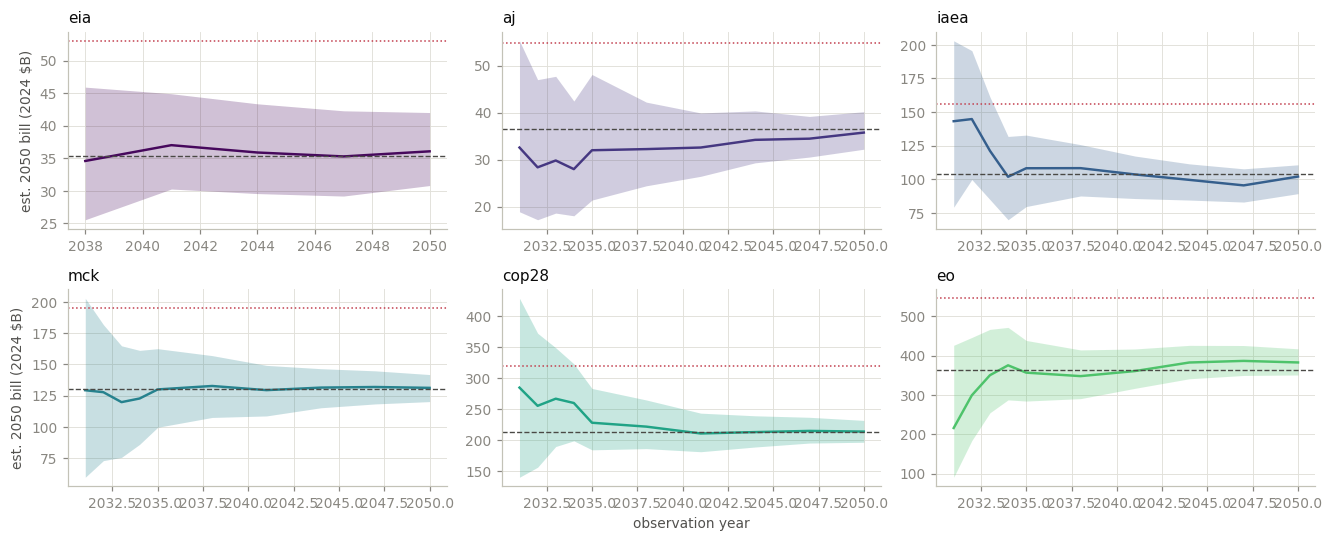

band: weighted 10th-90th pct, median over 10 noise histories; dashed: true bill; dotted: 1.5x cap


In [7]:
# ---- d11: running estimate fan, middle anchor world, middle noise ----------------
LV_MID = (0.30, 0.10)
fig, axes = plt.subplots(2, 3, figsize=(ps.W1 * 1.9, 5.0))
for ax, ab in zip(axes.ravel(), SCHEDULES):
    w0 = ANCH[ab]["p50"]
    sig, tau = LV_MID
    L0, n = LOGOCC[ab], N_UNITS[ab]
    var = tau ** 2 + sig ** 2 / n
    K = L0.shape[1]
    order = BILL_ORDER[ab]
    bills_sorted = B2050[ab][order]
    band = np.empty((R, K, 3))
    for r_ in range(R):
        eta = rng.normal(0, tau, size=K)
        zbar = rng.normal(0, 1, size=K) * (sig / np.sqrt(n))
        Y = L0[w0] + eta + zbar
        D = (L0 - Y[None, :]) ** 2 / (2 * var)[None, :]
        cl = -np.cumsum(D, axis=1)
        cl -= cl.max(axis=0, keepdims=True)
        W = np.exp(cl)
        for j in range(K):
            band[r_, j] = wquant(bills_sorted, W[order, j])
    med = np.median(band, axis=0)              # (K, 3)
    ax.fill_between(OBSCAL[ab], med[:, 0], med[:, 2], color=ps.SCHED_C[ab],
                    alpha=0.25, lw=0)
    ax.plot(OBSCAL[ab], med[:, 1], color=ps.SCHED_C[ab], lw=1.6)
    ax.axhline(B2050[ab][w0], color=ps.BASE_C, lw=0.9, ls="--")
    ax.axhline(1.5 * P50BILL[ab], color=ps.ACCENT["red"], lw=1.0, ls=":")
    ax.set_title(ab)
axes[1, 1].set_xlabel("observation year")
axes[0, 0].set_ylabel("est. 2050 bill (2024 $B)")
axes[1, 0].set_ylabel("est. 2050 bill (2024 $B)")
fig.tight_layout()
ps.savefig(fig, FIGURES / f"d11_running_bill_fan_noisy{SFX}.png")
plt.show()
print("band: weighted 10th-90th pct, median over 10 noise histories; "
      "dashed: true bill; dotted: 1.5x cap")


## B18 — cap exceedance with noisy data (spend-aware standard)

**Amendment (2026-08-25, Ethan; logged in `status.md`).** The exceedance
observer is now spend-aware: besides the noisy unit costs, it reads the
government's own outlay ledger (the cumulative subsidy paid so far — the
government's own checkbook, observed exactly), every calendar year. Each
candidate world's total bill is scored as the observed sunk spend plus that
world's remaining payments. Three consequences, all by construction:

- once actual spend reaches the cap, no candidate total can stay below it,
  so every truly exceeding world is flagged by 2050 at the latest (the
  ledger backstop; `share_detected` is 1 by construction);
- the backstop cannot fire on a world that never exceeds the cap (its spend
  never gets there), so it adds zero false alarms — the alarm bar keeps the
  stage-2 conformal calibration on the sampled non-exceeding histories, and
  is now also verified on the held-out sample (`fpr_holdout`);
- spend at detection can overshoot the cap by at most one year's payment
  accrual, because the ledger is read annually.

Spend enters the update additively only — never to tell worlds apart —
because in-model payments are exact shadow prices and would identify the
world instantly (the perfectly-informed-government wrinkle, stated in
`methods.md`). The cap grid is extended below 1.0 times the middle-world
bill, down to the cap whose starting probability of exceedance reaches
about 75% (the 25th-percentile bill). Rows still need at least 30 worlds on
each side. Every row carries the starting probability of exceeding X, plus
the pre-amendment costs-only observer's share detected and median year as
reference columns.

In [8]:
DET2_150 = {}
rows = []
for ab in SCHEDULES:
    tr = B2050[ab][SAMP[ab]]
    bills_s = BILLS_T[ab][SAMP[ab]]             # (600, 20) annual sunk spend
    trh = B2050[ab][HOLDW[ab]]
    for lv in LEVELS:
        ex0 = RES3[(ab, lv)]["ex"]              # costs-only, (600, R, K, nM)
        ex1 = RES3[(ab, lv)]["ex_spend"]        # spend-aware, (600, R, 20, nM)
        exh = RESH3[(ab, lv)]["ex_spend"]       # holdout,     (300, R, 20, nM)
        for k, m in enumerate(MULT):
            Xab = float(m * P50BILL[ab])
            prior = float(EXCEED[ab][:, k].mean())
            is_ex = tr > Xab
            if prior > PRIOR_CEIL or is_ex.sum() < 30 or (~is_ex).sum() < 30:
                continue
            # spend-aware alarm (the standard): conformal bar on the sampled
            # non-exceeding histories, plus the annual ledger backstop
            c = conformal_bar(ex1[~is_ex][:, :, :, k].max(axis=2).ravel())
            B_ex = bills_s[is_ex]               # (nex, 20)
            hit = (ex1[is_ex][:, :, :, k] > c) | (B_ex[:, None, :] > Xab)
            fired = hit.any(axis=2)             # all True by construction
            firsty = 2031 + hit.argmax(axis=2)  # (nex, R), annual grid
            nex = int(is_ex.sum())
            paid = B_ex[np.arange(nex)[:, None], firsty - 2031]
            tot = np.repeat(tr[is_ex][:, None], R, axis=1)
            uj = np.searchsorted(OBSCAL[ab], firsty, side="right") - 1
            units = np.where(uj >= 0, CUMU[ab][np.clip(uj, 0, None)], 0.0)
            goodh = trh <= Xab
            fprh = (float((exh[goodh][:, :, :, k] > c).any(axis=2).mean())
                    if goodh.sum() >= 30 else None)
            # costs-only reference (the pre-amendment observer)
            bar0 = conformal_bar(ex0[~is_ex][:, :, :, k].max(axis=2).ravel())
            hit0 = ex0[is_ex][:, :, :, k] > bar0
            f0 = hit0.any(axis=2)
            y0 = OBSCAL[ab][hit0.argmax(axis=2)][f0]
            if m == 1.5:
                DET2_150[(ab, lv)] = dict(worlds=SAMP[ab][is_ex], fired=fired,
                                          firsty=firsty)
            pq = lambda q: round(float(np.percentile(paid[fired], q)), 1)
            rows.append(dict(
                schedule=ab, sigma=lv[0], tau=lv[1], mult=m, X_2024B=round(Xab, 1),
                prior_exceed=round(prior, 3), n_exceed_worlds=nex,
                share_detected=round(float(fired.mean()), 3),
                median_det_year=float(np.median(firsty[fired])),
                q25_det_year=float(np.percentile(firsty[fired], 25)),
                q75_det_year=float(np.percentile(firsty[fired], 75)),
                median_units_at_det=float(np.median(units[fired])),
                paid_at_det_p05_2024B=pq(5), paid_at_det_p25_2024B=pq(25),
                paid_at_det_p50_2024B=pq(50), paid_at_det_p75_2024B=pq(75),
                paid_at_det_p95_2024B=pq(95),
                median_share_paid=round(float(np.median((paid / tot)[fired])), 3),
                fpr_holdout=None if fprh is None else round(fprh, 3),
                costsonly_share_detected=round(float(f0.mean()), 3),
                costsonly_median_det_year=int(np.median(y0)) if f0.any() else None))
b17 = pd.DataFrame(rows)
b17.to_csv(EXPORTS / f"b17_exceedance_noisy{SFX}.csv", index=False)
head = b17[b17["mult"].isin([1.0, 1.5, 2.0]) & (b17["sigma"] == 0.30)]
print("headline rows (middle noise level):")
print(head.to_string(index=False))
print("\nspend-aware p95 paid / cap, worst point per schedule (mid noise):")
mid = b17[b17["sigma"] == 0.30]
for ab in SCHEDULES:
    d_ = mid[mid["schedule"] == ab]
    print(f"  {ab}: {(d_['paid_at_det_p95_2024B'] / d_['X_2024B']).max():.2f}")


headline rows (middle noise level):
schedule  sigma  tau  mult  X_2024B  prior_exceed  n_exceed_worlds  share_detected  median_det_year  q25_det_year  q75_det_year  median_units_at_det  paid_at_det_p05_2024B  paid_at_det_p25_2024B  paid_at_det_p50_2024B  paid_at_det_p75_2024B  paid_at_det_p95_2024B  median_share_paid  fpr_holdout  costsonly_share_detected  costsonly_median_det_year
     eia    0.3  0.1   1.0     35.4         0.486              167             1.0           2038.0        2038.0        2041.0                 33.0                    2.9                    3.5                    4.2                   13.5                   32.1              0.072        0.036                     0.795                       2038
     eia    0.3  0.1   1.5     53.1         0.174               60             1.0           2038.0        2038.0        2041.0                 33.0                    3.7                    4.0                    4.2                   16.3                   41.0   

saved -> figures\d12_exceedance_by_cap_noisy_relo.png


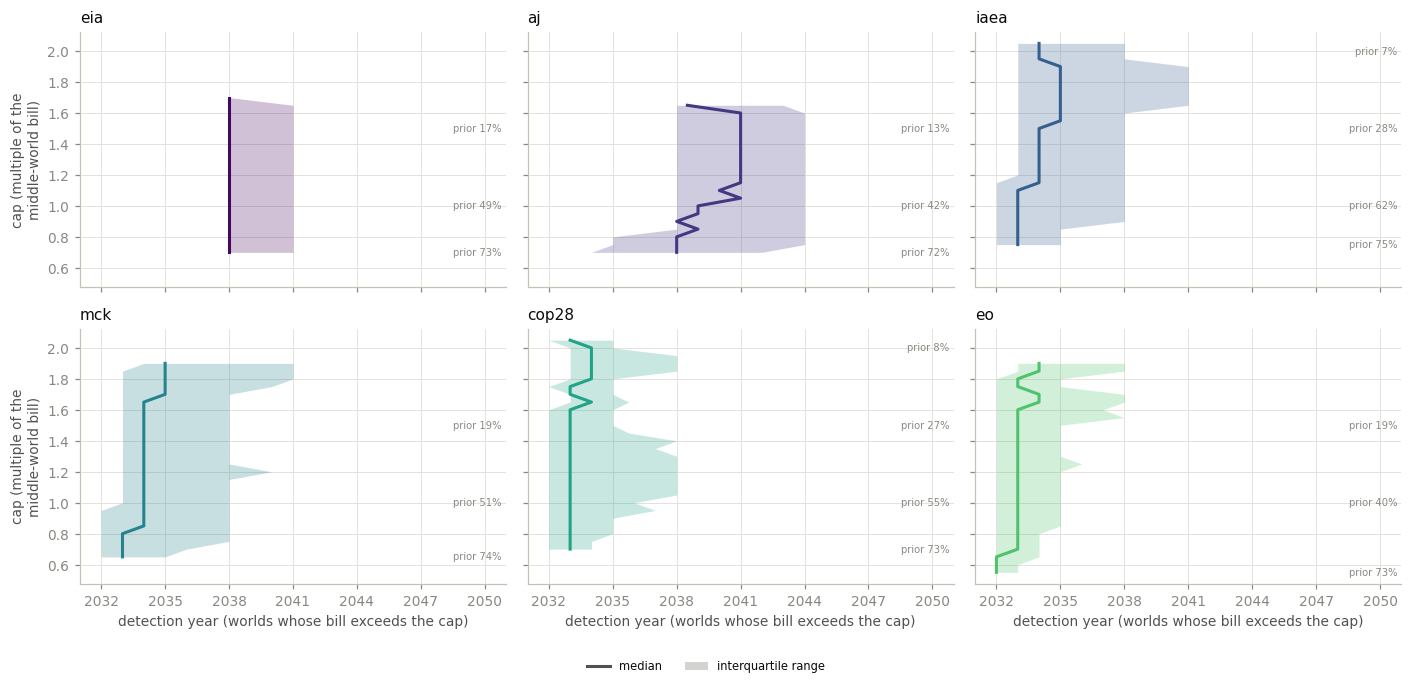

In [9]:
# ---- d12: detection year vs cap (spend-aware standard; middle noise) --------------
# Year on the x-axis, cap on the y-axis; median + interquartile band across
# exceeding worlds and noise histories; faint labels carry the starting
# probability at selected caps. Restyled 2026-08-25 (amendment).
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

b17m = b17[b17["sigma"] == 0.30]
fig, axes = plt.subplots(2, 3, figsize=(ps.W3, 6.2), sharey=True, sharex=True)
for ax, ab in zip(axes.ravel(), SCHEDULES):
    d = b17m[b17m["schedule"] == ab].sort_values("mult")
    col = ps.SCHED_C[ab]
    ax.fill_betweenx(d["mult"], d["q25_det_year"], d["q75_det_year"],
                     color=col, alpha=0.25, lw=0)
    ax.plot(d["median_det_year"], d["mult"], color=col, lw=2.0)
    for m_ in (float(d["mult"].min()), 1.0, 1.5, 2.0):
        rr = d[np.isclose(d["mult"], m_)]
        if len(rr):
            ax.annotate(f"prior {rr['prior_exceed'].iloc[0]:.0%}", (0.99, m_),
                        xycoords=ax.get_yaxis_transform(), fontsize=6.5,
                        color=ps.FAINT, ha="right", va="center")
    ax.set_title(ab)
    ax.set_xlim(2031, 2051)
    ax.set_xticks([2032, 2035, 2038, 2041, 2044, 2047, 2050])
for ax in axes[:, 0]:
    ax.set_ylabel("cap (multiple of the\nmiddle-world bill)")
for ax in axes[1, :]:
    ax.set_xlabel("detection year (worlds whose bill exceeds the cap)")
handles = [Line2D([], [], color=ps.MUTED, lw=2.0, label="median"),
           Patch(facecolor=ps.MUTED, alpha=0.25, label="interquartile range")]
fig.tight_layout(rect=(0, 0.05, 1, 1))
fig.legend(handles=handles, loc="lower center", ncol=2, fontsize=7.5,
           frameon=False)
ps.savefig(fig, FIGURES / f"d12_exceedance_by_cap_noisy{SFX}.png")
plt.show()


saved -> figures\d13_paid_by_cap_noisy_relo.png


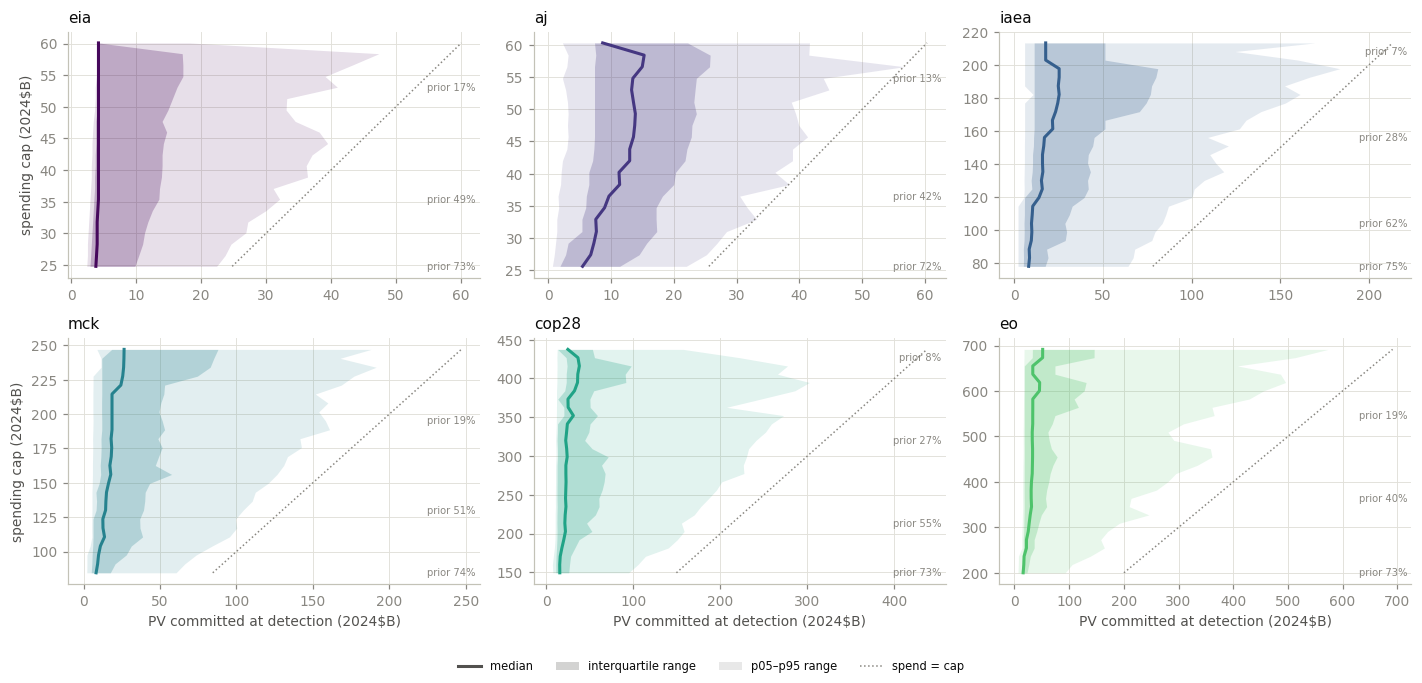

In [10]:
# ---- d13: PV committed at detection vs cap (2024$B axes; middle noise) ------------
# Both axes in dollars; light band p05-p95, dark band interquartile, dotted
# diagonal spend = cap (a hard bound up to one year's accrual). New figure,
# 2026-08-25 amendment.
fig, axes = plt.subplots(2, 3, figsize=(ps.W3, 6.2))
for ax, ab in zip(axes.ravel(), SCHEDULES):
    d = b17m[b17m["schedule"] == ab].sort_values("mult")
    col = ps.SCHED_C[ab]
    ax.fill_betweenx(d["X_2024B"], d["paid_at_det_p05_2024B"],
                     d["paid_at_det_p95_2024B"], color=col, alpha=0.13, lw=0)
    ax.fill_betweenx(d["X_2024B"], d["paid_at_det_p25_2024B"],
                     d["paid_at_det_p75_2024B"], color=col, alpha=0.25, lw=0)
    ax.plot(d["paid_at_det_p50_2024B"], d["X_2024B"], color=col, lw=2.0)
    ax.plot(d["X_2024B"], d["X_2024B"], color=ps.FAINT, lw=1.0, ls=":")
    for m_ in (float(d["mult"].min()), 1.0, 1.5, 2.0):
        rr = d[np.isclose(d["mult"], m_)]
        if len(rr):
            ax.annotate(f"prior {rr['prior_exceed'].iloc[0]:.0%}",
                        (0.99, rr["X_2024B"].iloc[0]),
                        xycoords=ax.get_yaxis_transform(), fontsize=6.5,
                        color=ps.FAINT, ha="right", va="center")
    ax.set_title(ab)
for ax in axes[:, 0]:
    ax.set_ylabel("spending cap (2024$B)")
for ax in axes[1, :]:
    ax.set_xlabel("PV committed at detection (2024$B)")
handles = [Line2D([], [], color=ps.MUTED, lw=2.0, label="median"),
           Patch(facecolor=ps.MUTED, alpha=0.25, label="interquartile range"),
           Patch(facecolor=ps.MUTED, alpha=0.13, label="p05–p95 range"),
           Line2D([], [], color=ps.FAINT, lw=1.0, ls=":", label="spend = cap")]
fig.tight_layout(rect=(0, 0.05, 1, 1))
fig.legend(handles=handles, loc="lower center", ncol=4, fontsize=7.5,
           frameon=False)
ps.savefig(fig, FIGURES / f"d13_paid_by_cap_noisy{SFX}.png")
plt.show()


## B19 — the cost of waiting, now as a function of data quality

For each schedule and noise level, over the truly bad histories: the bill
already paid by the detection year (median, present value), against the full
2031–2050 bill, plus the share of histories never detected by 2050. The
difference between the low-noise and high-noise rows is the value of better
cost surveillance, stated in billions: cleaner data means earlier detection
means less money committed before anyone can know.

In [11]:
rows = []
for ab in SCHEDULES:
    isb = IS_BAD_S[ab]
    wb = SAMP[ab][isb]
    yrs = OBSCAL[ab]
    for lv in LEVELS:
        d1 = DET3[(ab, lv)]
        fired, firstj = d1["fired"], d1["firstj"]       # (300, R)
        det_year = yrs[firstj]
        tot = B2050[ab][wb]                             # (300,)
        widx = np.repeat(wb[:, None], R, axis=1)
        paid = BILLS_T[ab][widx, det_year - 2031]       # (300, R)
        row = dict(schedule=ab, sigma=lv[0], tau=lv[1],
                   c1_share_never_detected=round(float(1 - fired.mean()), 3))
        if fired.any():
            totm = np.repeat(tot[:, None], R, axis=1)
            row.update(
                c1_median_paid_at_det_2024B=round(float(np.median(paid[fired])), 1),
                c1_median_total_2024B=round(float(np.median(totm[fired])), 1),
                c1_median_share_paid=round(float(np.median(paid[fired] / totm[fired])), 3))
        if (ab, lv) in DET2_150:
            d2 = DET2_150[(ab, lv)]
            we, f2, dy2 = d2["worlds"], d2["fired"], d2["firsty"]
            widx2 = np.repeat(we[:, None], R, axis=1)
            paid2 = BILLS_T[ab][widx2, dy2 - 2031]
            tot2 = np.repeat(B2050[ab][we][:, None], R, axis=1)
            row["c2_150_share_never_detected"] = round(float(1 - f2.mean()), 3)
            if f2.any():
                row.update(
                    c2_150_median_paid_at_det_2024B=round(float(np.median(paid2[f2])), 1),
                    c2_150_median_share_paid=round(float(np.median(paid2[f2] / tot2[f2])), 3))
        rows.append(row)
b18 = pd.DataFrame(rows)
b18.to_csv(EXPORTS / f"b18_cost_of_waiting_noisy{SFX}.csv", index=False)
print(b18.to_string(index=False))


schedule  sigma  tau  c1_share_never_detected  c1_median_paid_at_det_2024B  c1_median_total_2024B  c1_median_share_paid  c2_150_share_never_detected  c2_150_median_paid_at_det_2024B  c2_150_median_share_paid
     eia   0.15 0.05                    0.373                          4.2                   44.9                 0.074                          0.0                              4.1                     0.069
     eia   0.30 0.10                    0.497                          4.2                   48.6                 0.076                          0.0                              4.2                     0.069
     eia   0.50 0.20                    0.600                         16.4                   51.5                 0.299                          0.0                             17.6                     0.295
      aj   0.15 0.05                    0.225                         13.6                   41.6                 0.285                          0.0                    

## B20 — the bias experiment: systematic overruns

Random scatter and systematic overrun are different problems. Here every
project comes in 30% above the world's true cost (m = 0.30), at the middle
noise level, and two observers face the data:

- the **informed** observer knows the 30% bias and corrects for it. Its
  correction cancels the bias exactly, so its results are, by construction,
  the middle-noise results from B16 — this identity is stated rather than
  re-simulated;
- the **naive** observer assumes no bias. It tunes its alarm on its own
  assumed (no-bias) world — the same calibration as B16 — and then faces the
  biased data.

The naive observer's realized false-alarm rate, against its 5% budget, is the
measured cost of mistaking systematic overruns for an expensive world. Its
detection years on truly bad worlds also come earlier — for the wrong
reason.

In [12]:
M_BIAS = 0.30
rows = []
for ab in SCHEDULES:
    isb = IS_BAD_S[ab]
    yrs = OBSCAL[ab]
    c = CSTAR3[(ab, LV_MID)]                    # the naive observer's own bar
    naive = weighted_sweep(ab, LV_MID, SAMP[ab], m_data=M_BIAS, m_obs=0.0)
    post = naive["post"]
    fpr = float((post[~isb].max(axis=2) > c).mean())
    pb = post[isb]
    hit = pb > c
    fired = hit.any(axis=2)
    years = yrs[hit.argmax(axis=2)]
    got = years[fired]
    inf_row = b15[(b15["schedule"] == ab) & (b15["sigma"] == LV_MID[0])].iloc[0]
    rows.append(dict(schedule=ab, observer="informed",
                     fpr_realized=inf_row["fpr_holdout"],
                     share_detected=inf_row["share_detected"],
                     median_det_year=inf_row["median_det_year"]))
    rows.append(dict(schedule=ab, observer="naive",
                     fpr_realized=round(fpr, 3),
                     share_detected=round(float(fired.mean()), 3),
                     median_det_year=int(np.median(got)) if fired.any() else None))
b19 = pd.DataFrame(rows)
b19.to_csv(EXPORTS / f"b19_bias_experiment{SFX}.csv", index=False)
print(b19.to_string(index=False))


schedule observer  fpr_realized  share_detected  median_det_year
     eia informed         0.040           0.503             2038
     eia    naive         0.327           0.854             2038
      aj informed         0.042           0.573             2044
      aj    naive         0.352           0.862             2038
    iaea informed         0.023           0.662             2038
    iaea    naive         0.309           0.876             2033
     mck informed         0.036           0.712             2038
     mck    naive         0.310           0.896             2033
   cop28 informed         0.027           0.696             2038
   cop28    naive         0.228           0.913             2033
      eo informed         0.041           0.803             2035
      eo    naive         0.265           0.955             2032


## B21 — verdict and carried caveats

Gates fixed in `status.md` before the run: **H1** — the main observer's
held-out false-alarm rate stays at or under 7.5% (the 5% budget plus a
sampling margin) everywhere. **H2** (soft) — low noise lands near the stage-2
tight-band results; gaps are reported and explained, not gated. **H3** — the
middle noise level still detects C1 by 2045 in every schedule for a PASS.

Carried caveats: the observer still knows the menu of possible worlds (the
ensemble) and the noise model itself — generous assumptions; sigma and tau
are declared dials, not estimates; every non-anchor bill is a three-anchor
interpolation with the stage-2 G2 honesty band; the build path is frozen
(information, never a recommendation); every quoted cap carries its starting
probability.

In [13]:
h1_max = float(b15["fpr_holdout"].max())
H1 = h1_max <= 0.075

lowrows = b15[b15["sigma"] == 0.15].set_index("schedule")
h2_gap = {ab: (None if pd.isna(lowrows.loc[ab, "median_det_year"])
               else int(lowrows.loc[ab, "median_det_year"])
               - int(S2MED[(ab, 0.05)])) for ab in SCHEDULES}

midrows = b15[b15["sigma"] == 0.30].set_index("schedule")
med_mid = {ab: midrows.loc[ab, "median_det_year"] for ab in SCHEDULES}
H3 = all(y is not None and not pd.isna(y) and y <= 2045 for y in med_mid.values())

verdict = "PASS" if (H1 and H3) else ("PARTIAL" if H1 else "FAIL")

b20 = pd.DataFrame([
    dict(metric="h1_fpr_holdout_max", value=round(h1_max, 3)),
    dict(metric="h1_gate_075", value=H1),
    *[dict(metric=f"h2_lownoise_minus_stage2d05_{ab}", value=h2_gap[ab])
      for ab in SCHEDULES],
    *[dict(metric=f"c1_median_det_year_mid_{ab}", value=med_mid[ab])
      for ab in SCHEDULES],
    dict(metric="h3_mid_noise_by2045", value=H3),
    dict(metric="verdict", value=verdict),
])
b20.to_csv(EXPORTS / f"b20_verdict{SFX}.csv", index=False)
print(b20.to_string(index=False))
print(f"\nSTAGE 3 VERDICT: {verdict}")


                           metric  value
               h1_fpr_holdout_max  0.051
                      h1_gate_075   True
  h2_lownoise_minus_stage2d05_eia      1
   h2_lownoise_minus_stage2d05_aj      6
 h2_lownoise_minus_stage2d05_iaea      3
  h2_lownoise_minus_stage2d05_mck      3
h2_lownoise_minus_stage2d05_cop28      2
   h2_lownoise_minus_stage2d05_eo      1
       c1_median_det_year_mid_eia   2038
        c1_median_det_year_mid_aj   2044
      c1_median_det_year_mid_iaea   2038
       c1_median_det_year_mid_mck   2038
     c1_median_det_year_mid_cop28   2038
        c1_median_det_year_mid_eo   2035
              h3_mid_noise_by2045   True
                          verdict   PASS

STAGE 3 VERDICT: PASS


In [14]:
stage3_tables = [f"b{i}" for i in range(14, 21)]
manifest = sorted(p.name for p in EXPORTS.glob(f"b*{SFX}.csv")
                  if p.name.split("_")[0] in stage3_tables) \
    + sorted(p.name for p in FIGURES.glob(f"d*{SFX}.png")
             if p.name.split("_")[0] in ["d09", "d10", "d11", "d12", "d13"])
print("outputs written by this notebook:")
for m_ in manifest:
    print(" ", m_)


outputs written by this notebook:
  b14_observation_calendar_relo.csv
  b15_detection_noisy_relo.csv
  b16_running_estimate_noisy_relo.csv
  b17_exceedance_noisy_relo.csv
  b18_cost_of_waiting_noisy_relo.csv
  b19_bias_experiment_relo.csv
  b20_verdict_relo.csv
  d09_noise_illustration_relo.png
  d10_detection_ecdf_noisy_relo.png
  d11_running_bill_fan_noisy_relo.png
  d12_exceedance_by_cap_noisy_relo.png
  d13_paid_by_cap_noisy_relo.png
